Code for only running autoencoder bootstrap iteration sweep in Colab -> GCS 
#### changelog 
+ v2- successfully runnig N iterations across all combinations
+ v3- adding WT CLNZ and streamlinecode. created N indepdenent bootstrap run code to evaluate staiblity of results. packaged resample function

In [3]:
!ls 


 autoencoder_cloud_requirements.txt
 autoencoder_train_cloud_v3_paramsweep_only.ipynb
 autoencoder_training_cloud_plot_results_v1.ipynb
 autoencoder_training_cloud_run_v1.ipynb
 autoencoder_training_cloud_v2_w_sweep.ipynb
 autoencoder_training.ipynb
 ax_modifier_functions_cloud.py
 class_matrix_results
 CLAUDE.md
 cloud_storage.py
 data
'DB index mean diff cohen_d posthoc test.csv'
 desktop.ini
 dropped_cell_ids_13_Jan_2026.json
 dropped_cells_analysis_13_Jan_2026.png
 dropped_cells_summary_13_Jan_2026.csv
 external_functions.py
 LICENSE
 lightning_autoencoder.code-workspace
 output
 paper_plot.mplstyle
 __pycache__
 README.md
 sample_data
 service_account_key.json
 sns_plotting_config.py
 sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error.png


In [4]:
# %load_ext autoreload
# %autoreload 2
# %pip install -r autoencoder_cloud_requirements.txt
%pip install -r autoencoder_cloud_requirements.txt -v 2>&1 | grep -E "Building|Successfully"

%matplotlib inline
import sys
import os
import logging #to suppress pytorch GPU output etc
import warnings
#supress specific future warnings and automatic lighitning outputs
logging.getLogger("lightning.pytorch.utilities.rank_zero").setLevel(logging.FATAL)
logging.getLogger("pytorch_lightning.utilities.rank_zero").setLevel(logging.WARNING)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore",r".*does not have many workers which may be a bottleneck.*")
warnings.filterwarnings("ignore",".*GPU available.*",category=UserWarning) # option 2: just filter out the GPU‐warning
#run import modules for analysis 
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import itertools
from tqdm import tqdm
import datetime
import pickle
import sklearn
from sklearn.metrics import davies_bouldin_score
print(f"matplotlib version: {matplotlib.__version__},sns version: {sns.__version__},pandas ver: {pd.__version__}")
#torch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning as L
from torch.utils.data import TensorDataset, DataLoader
from functools import partial
from joblib import Parallel, delayed 

#custom loads
from cloud_storage import save_to_gcs, load_parquet_from_gcs
from external_functions import *
from sns_plotting_config import *
from ax_modifier_functions_cloud import *
plt.style.use('paper_plot.mplstyle')
#colab kernel fixes 
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # Available on Colab
plt.rcParams['font.family'] = 'sans-serif'
## elsevier fig sizes https://www.elsevier.com/about/policies-and-standards/author/artwork-and-media-instructions/artwork-sizing

matplotlib version: 3.7.0,sns version: 0.12.1,pandas ver: 1.5.2


<Figure size 640x480 with 0 Axes>

In [5]:
# # Define the relative path to the src directory
# module_path = r'G:\My Drive\Colab notebooks\Function .py Storage\plot_posthoc_test\src\plot_posthoc_test'
# function_dir =  os.path.join(r'G:\\My Drive\\Colab notebooks\\', 'Function .py Storage')
# print(function_dir)
# if module_path not in sys.path:
#     sys.path.append(module_path)
# if function_dir not in sys.path:
#     sys.path.append(function_dir)
# # Import functions and classes from plot_stat_annotate
# from plot_stat_annotate import *



In [6]:
print(os.getcwd())

/content


## Process Data 


#### Create dataset object for resampling in bootstrapabs

In [7]:
folder_loc = '/Run Outputs/'
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
print(f"date tag: {date_tag}")
folder_name =folder_loc+  f"figure_5_postSVM_decoding_accuracy_and_PCA_plots_"+ date_tag + "/"

date tag: 13_Jan_2026


In [8]:
# new folder structure:
# outputs/                     # For trained models and results
# │   ├── models/                  # Trained model checkpoints
# │   ├── figures/                 # Generated figures
# │   └── logs/                    # Lightning logs
    
data_folder = os.getcwd() +"/data/"
output_folder = os.getcwd() +"/output/"
model_results_folder = output_folder + "/model_results/"
current_run_output = model_results_folder + f"{date_tag}\\"
all_figure_output_folder = output_folder +"/figures/"
fig_output = all_figure_output_folder + f"{date_tag}\\"
#make folders 
make_folder(output_folder)
make_folder(all_figure_output_folder)
make_folder(fig_output)
make_folder(model_results_folder)
make_folder(current_run_output)

'/content/output//model_results/13_Jan_2026\\'

In [ ]:
new_trial_df_filename = r"python-made_trial_timeseries_raster_2025-12-21 12.parquet"
#declare loc/names of files to read
load_dataset = True
save_norm_trial_dataset = True
# trial_df_filename = data_folder +  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_df_filename = data_folder +  new_trial_df_filename
if load_dataset:
    print(f"loading_dataset")
    trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
trial_tseries_df_norm.tail()

In [11]:
#once loaded, derive info from metadata
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ") #in external_functions.py
# note informative stats for refernce later if necessary
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = 'neuron_id', subj_name_col = 'subject_name')#.rename({'neuron_id': "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')['neuron_id'].nunique()
print(n_total_units)
print(n_total_units.sum())
subject_stage_info_df.tail()

geno_day
Het CLNZ         840
Het VEH          851
Het postCLNZ     914
WT CLNZ          985
WT VEH          1034
Name: neuron_id, dtype: int64
4624


,subject_name,geno_day,task_phase_vec,neuron_id,num_enriched_units,num_units,trial_num,count_of_trials,over_5
196,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-100, 9_3_HET_RS3-129, 9_3_HET_RS3...",23,171,"[3, 5]",2,"[False, False]"
197,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-124, 9_3_HET_RS3-129, 9_3_HET_RS3...",10,171,"[17, 19, 21]",3,"[True, True, True]"
198,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-128, 9_3_HET_RS3-138, 9_3_HET_RS3...",12,171,"[18, 20]",2,"[True, True]"
199,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-129, 9_3_HET_RS3-138, 9_3_HET_RS3...",16,171,"[12, 13, 14, 15, 16]",5,"[True, True, True, True, True]"
200,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-130, 9_3_HET_RS3-169, 9_3_HET_RS3...",4,171,"[34, 35, 36, 38]",4,"[True, True, True, True]"


#### save class matrix store for loading later

In [12]:
# ## helper functions imported from phase_enrich_timeseries_decode.py module
def get_dataset_names_in_geno(dataset_name_by_geno_day,
                              geno_day,
                              subject_name_col = 'subject_name'):
    datasets_in_geno = dataset_name_by_geno_day.loc[dataset_name_by_geno_day.geno_day == geno_day,subject_name_col].values[0] #get name of datasets in current geno_day setup
    return datasets_in_geno

 ## imported subfunc for cuDF speedup
def get_tseries_of_dataset(timeseries_df, 
                           dataset_name, 
                           subject_name_col = 'subject_name'):
    #get time-series that are occurign in phase of interest
    dataset_df_slice = timeseries_df.loc[timeseries_df[subject_name_col] == dataset_name]
    return dataset_df_slice

def get_tseries_in_phase(timeseries_df, phase_name):
    phase_dataset_df_slice = timeseries_df.loc[timeseries_df.task_phase_vec == phase_name]
    return phase_dataset_df_slice

def get_tseries_phase_enrich_cells(tseries_df, unit_ID_col, enrichment_ID_df, dataset_name, e_phase_name):
    enrich_in_phase_unit_IDs = get_dataset_units_enrich_in_phase(enrichment_ID_df, unit_ID_col, dataset_name, e_phase_name) #get unit IDs that are enriched in phase of interest
    enrich_in_phase_dataset_df = tseries_df.loc[tseries_df[unit_ID_col].isin(enrich_in_phase_unit_IDs)]#get unit time-series only if they enriched in phase of interest
    return enrich_in_phase_dataset_df, enrich_in_phase_unit_IDs

def get_dataset_units_enrich_in_phase(enrich_unit_by_name_phase_df,
                                       unit_ID_col,
                                         dataset_name,
                                           stage_of_interest,
                                           subject_name_col = 'subject_name'):
    name_mask = enrich_unit_by_name_phase_df[subject_name_col] == dataset_name
    phase_mask = enrich_unit_by_name_phase_df.task_phase_vec == stage_of_interest
    enrich_in_phase_unit_IDs =enrich_unit_by_name_phase_df.loc[phase_mask&name_mask, unit_ID_col].values[0]
    return enrich_in_phase_unit_IDs

def horzcat_all_trials(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=None):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col]
    grouped = {
        trial: group.set_index(unit_col_name)[tseries_cols]
        for trial, group in timeseries_df.groupby('trial_num', sort=False)
    }
    return pd.concat(grouped.values(), axis=1)

In [13]:
def horzcat_all_trials_original(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=None):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col] 
    trial_slice_storage = []
    for trial in timeseries_df.trial_num.unique():
        trial_slice = timeseries_df.loc[timeseries_df.trial_num == trial].set_index(unit_col_name)
        trial_slice_storage.append(trial_slice.loc[:,tseries_cols])
    return pd.concat(trial_slice_storage, axis=1)



# Test
result_orig = horzcat_all_trials_original(trial_tseries_df_norm, numeric_col,'neuron_id')
result_opt = horzcat_all_trials(trial_tseries_df_norm, numeric_col,'neuron_id')

print("Identical:", result_orig.equals(result_opt))
print("Shape match:", result_orig.shape == result_opt.shape)
print("Columns match:", list(result_orig.columns) == list(result_opt.columns))
print("Index match:", list(result_orig.index) == list(result_opt.index))

Identical: True
Shape match: True
Columns match: True
Index match: True


In [14]:
def make_dataset_matrix_store_only(phase_names, 
                                   trial_tseries_df_norm,
                                   unit_ID_col,
                                   enrich_unit_ID_by_name_df,
                                    numeric_col,
                                    trial_list_by_dataset,
                                   dataset_name_by_geno_day,
                                   phase_enrichment_by_subj,
                                     subject_name_col = 'subject_name'):
    """TO- create a dict where key1 = stage the pseudopop is enriched in, key 2 = stage to look for activity of, and key 3- genotype of current datset"""
    ppop_data,stage_geno_tseries = dict(), dict()
    iter_ct = 0
    for e_phase in phase_names:
        ppop_data[e_phase],stage_geno_tseries[e_phase] = {},{}
        print("Get enrich in ",e_phase, "act. in ", phase_names)

        for act_phase in phase_names:
            datasets_w_phase_act = trial_list_by_dataset.loc[trial_list_by_dataset.task_phase_vec == act_phase][subject_name_col].unique()
            ppop_data[e_phase][act_phase],stage_geno_tseries[e_phase][act_phase]= {},{}

            for geno_day in dataset_name_by_geno_day.geno_day.unique():
                datasets_in_geno = get_dataset_names_in_geno(dataset_name_by_geno_day,geno_day)
                geno_dataset_w_act = [name for name in datasets_in_geno if name in datasets_w_phase_act]
                current_ppop_draw = dict()
                
                for dataset in geno_dataset_w_act:
                    iter_ct = iter_ct+1
                    #check if > 0 cells are enriched in stage
                    if phase_enrichment_by_subj.set_index(subject_name_col).loc[dataset, e_phase] > 0:
                        phase_dataset_df = get_tseries_in_phase(get_tseries_of_dataset(trial_tseries_df_norm,dataset), act_phase)
                        e_in_phase_data_df,e_in_stage_ID =get_tseries_phase_enrich_cells(phase_dataset_df, unit_ID_col,
                                                                                         enrich_unit_ID_by_name_df, dataset, e_phase)
                        current_ppop_draw[dataset] =  horzcat_all_trials(e_in_phase_data_df,numeric_col, unit_ID_col)
                ppop_data[e_phase][act_phase][geno_day] =current_ppop_draw
    return ppop_data

In [15]:
from google.oauth2 import service_account
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload

lightning_autoencoder_googleID = '1D6Vg0uPWJD4hHEaS4nDtFPNBoWZY2ovN'
# ============ SETUP (run once per session) ============
SCOPES = ['https://www.googleapis.com/auth/drive']
SERVICE_ACCOUNT_FILE = 'service_account_key.json'
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)
drive_service = build('drive', 'v3', credentials=creds)
drive_service

In [16]:

def save_to_drive(local_path, drive_filename, folder_id=None):
    """Upload file to Google Drive. Optionally specify a folder ID."""
    if not os.path.exists(local_path):
        print(f"Warning: {local_path} does not exist, skipping upload")
        return None
    metadata = {'name': drive_filename}
    if folder_id:
        metadata['parents'] = [folder_id]
    media = MediaFileUpload(local_path)
    file = drive_service.files().create(body=metadata,
                                        media_body=media,
                                        fields='id',
                                        supportsAllDrives=True).execute()
    # Transfer ownership to your personal account
    drive_service.permissions().create(
        fileId=file_id,
        transferOwnership=True,
        body={'type': 'user', 'role': 'owner',
               'emailAddress': "13carlosj@gmail.com"}).execute()
    print(f"Saved to Drive: {drive_filename}")
    file_id = file.get('id')


    return 

def create_drive_folder(folder_name, parent_id=None):
    metadata = {
        'name': folder_name,
        'mimeType': 'application/vnd.google-apps.folder'
    }
    if parent_id:
        metadata['parents'] = [parent_id]
    folder = drive_service.files().create(body=metadata, fields='id').execute()
    return folder.get('id')

# # In your training loop:
# pd.concat(bootstrap_storage).to_parquet(checkpoint_file)
# save_to_drive(checkpoint_file, f"bootstrap_checkpoint_{date_tag}.parquet")

In [17]:
from google.cloud import storage

client = storage.Client.from_service_account_json('service_account_key.json')
bucket = client.bucket('colab_autoencoder_output')

def save_to_gcs(local_path, blob_name):
    blob = bucket.blob(blob_name)
    blob.upload_from_filename(local_path)
    print(f"Uploaded: gs://colab_autoencoder_output/{blob_name}")

# Test it
save_to_gcs('/content/README.md', 'README.md')

Uploaded: gs://colab_autoencoder_output/README.md


In [18]:
local_colab_folder = os.getcwd() + "/class_matrix_results/"
#make folders 
make_folder(local_colab_folder)

'/content/class_matrix_results/'

In [19]:
# save store class_matrix_store
class_matrix_save_file =  f"pseudopop_ensemble_activity_dict_{date_tag}.pickle"
load_filename = data_folder + f"pseudopopulation_ensemble_activity_store_20_Jun_2025.pickle"

#set options
make_class_matrix = True
save_class_matrix = True
write_to_GCS = True
neuron_ID_col = 'neuron_id'
#set loop
if make_class_matrix: ##create class matrix store
    #extract enrichment to see what subjects had 0 enriched cells 
    neuron_enrichment =  trial_tseries_df_norm.groupby(['subject_name', 'geno_day', 'neuron_id'])[stage_names].mean().reset_index()
    phase_enrichment_by_subj = neuron_enrichment[list(stage_names) + ['subject_name', 'geno_day']].groupby(by = ['subject_name', 'geno_day']).sum().reset_index()
    
    #filter by subjects with > 1 trial in a given stage 
    trial_list_by_dataset= subject_stage_info_df.loc[:,['subject_name', 
                                                        'geno_day', 'task_phase_vec', 'trial_num', 'count_of_trials']]
    trial_list_by_dataset= trial_list_by_dataset[trial_list_by_dataset.count_of_trials >1]##important- threshold to take datasets with >1 trials per section (to have enough variety in neural activity)
    enrich_unit_ID_by_name_df = subject_stage_info_df.loc[:,['subject_name', 'geno_day', 'task_phase_vec', neuron_ID_col]]
    dataset_name_by_geno_day = enrich_unit_ID_by_name_df.groupby('geno_day')['subject_name'].unique().reset_index()
    
    #use premade information to create new matrix
    class_matrix_store = make_dataset_matrix_store_only(stage_names,
                                                        trial_tseries_df_norm,
                                                        unit_ID_col = neuron_ID_col,
                                                        enrich_unit_ID_by_name_df = enrich_unit_ID_by_name_df, 
                                                        numeric_col = numeric_col,
                                                        trial_list_by_dataset = trial_list_by_dataset,
                                                        dataset_name_by_geno_day = dataset_name_by_geno_day,
                                                        phase_enrichment_by_subj = phase_enrichment_by_subj)
    if save_class_matrix:
        print(f"Saving {class_matrix_save_file}")
        with open(local_colab_folder + class_matrix_save_file, 'wb') as handle:
            pickle.dump(class_matrix_store, handle, protocol=pickle.HIGHEST_PROTOCOL)
            if write_to_GCS:
                print(f"Writing to CGS: {class_matrix_save_file}")
                save_to_gcs(local_colab_folder + class_matrix_save_file, local_colab_folder + class_matrix_save_file)
else: #if you don't make or save one, you load one 
    print(f" loading file: {load_filename}")
    with open(load_filename, 'rb') as handle:
        class_matrix_store = pickle.load(handle)

Get enrich in  Early_IA_Correct act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_IA_Error act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_RS_Correct act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_RS_Error act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Late_IA act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Late_RS act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Saving pseudopop_ensemble_activity_dict_13_Jan_2026.pickle
Writing to CGS: pseudopop_ensemble_activity_dict_13_Jan_2026.pickle
Uploaded: gs://colab_autoencoder_output//content/class_

## Test Pytorch Lightning Autoencoder function on sample data 

#### Define pytorch lightining functions

In [20]:
## separate into function 
def return_train_test_tensorDataset(input_data, input_labels:np.array, shuffle:bool = True, test_on_train:bool = True):
    '''TO- given numpy matrices, and optional shuffle, return 2 pytorch test and train datasets in tensor format'''
    #moved from outside func to inside
    input_data = input_data.values.T #.T.values of concat matrix is to reshape mat into what scikit wants from you
    #get indices
    assert input_data.shape[0] > 0
    rng = np.random.default_rng()
    n_samples = input_data.shape[0]
    input_data_index =np.arange(0,n_samples) 
    permuted_index = rng.permutation(input_data_index)

    if test_on_train:
        if shuffle:
            train_index = permuted_index
            test_index = permuted_index
        else: #non shuffle, test set = train set
            train_index = input_data_index
            test_index = train_index
    else: #if test not == train
        if shuffle:
            train_index = permuted_index[0:n_samples//2]
            test_index = permuted_index[n_samples//2:n_samples]
        else:
            train_index = input_data_index[0:n_samples//2]
            test_index =  input_data_index[n_samples//2:n_samples]
        
    ##extract data of interest 
    train_data= torch.tensor(input_data[train_index,:], dtype=torch.float32)
    train_labels= torch.tensor(input_labels[train_index], dtype=torch.float32)
    
    test_data = torch.tensor(input_data[test_index,:], dtype=torch.float32)
    test_labels = torch.tensor(input_labels[test_index], dtype=torch.float32)
    ## consolidate into TEnsorDataset objects
    train_dataset = TensorDataset(train_data, train_labels)
    test_dataset = TensorDataset(test_data, test_labels)
    
    return train_dataset, test_dataset

In [21]:
weight_decay = 1e-2
class dropout_net(nn.Module):
    def __init__(self, layer_1_input=50, bottleneck_input = 9, latent_space_size = 2,dropout= 0):
        super().__init__()
        ### Using a bottleneck latent dimension of 2
        self.encoder = nn.Sequential(
            nn.Linear(layer_1_input,bottleneck_input),nn.Mish(),nn.Dropout(dropout),nn.Linear(bottleneck_input, latent_space_size)) #from 250 node layer to 3D bottle neck/ latent space 
        self.decoder = nn.Sequential(
            nn.Linear(latent_space_size,bottleneck_input),nn.Mish(),nn.Linear(bottleneck_input, layer_1_input))

    def forward(self, x):      
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# define the LightningModule
class LitAutoEncoder(L.LightningModule):
    def __init__(self, dropout_net, **model_kwargs):#load/import  model 
        super().__init__()
        self.save_hyperparameters()# save hyperparameters to self.hparams
        self.model = dropout_net(**model_kwargs)# instantiate your model
        
    def configure_optimizers(self):
        #NEW using  weight decay baked into AdamW
        optimizer = optim.AdamW(self.parameters(),weight_decay = weight_decay, lr=0.0125)### Define your loss function (training criterion). tempw as at 0.0125, reset to 0.013
        return optimizer 
 # training_step of the LightningModule configure how your training routine behaves with a batch of training data:      
    def training_step(self, batch, batch_index):
        (data, target) = batch #unpack traiing data 
        output = self.forward(data) #get reconstruction output of model
        loss = F.mse_loss(output, data)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)# logs metrics for each training_step, & the average across the epoch, to the progress bar and logger
        return loss
    
    def forward(self, x):
        # here you define how to get outputs from inputs
        return self.model(x)

    def encode(self, x):
        # directly reach into the wrapped nn.Module
        return self.model.encoder(x)

In [22]:
class LossHistory(L.Callback):
    ## class used to store loss history of trainer module through callbacks to the trainer
    def __init__(self):
        super().__init__()
        self.train_losses = []

    def on_train_epoch_end(self, trainer, pl_module):        # pl_module.log(..., on_epoch=True) ensures 'train_loss' is in callback_metrics
        loss = trainer.callback_metrics.get("train_loss")
        if loss is not None: # .item() to turn it into a Python float
            self.train_losses.append(loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get("val_loss")
        if loss is not None:
            self.val_losses.append(loss.item())

In [23]:
def lightning_encode(model, test_loader):
    ### Push data into latent space without retreiving
    model.freeze()
    latent =[]
    labels = []
    # device = next(model.parameters()).device
    # print("Model is on:", device)
    for batch_idx, (data, target) in enumerate(test_loader): #target is true labels y
        latentSpace = model.encode(data)
        #store results
        latent.append(latentSpace.detach().numpy())
        labels.append(target.detach().numpy())
    return np.vstack(latent),  np.hstack(labels) # this should match the dim of latent_embeddings, so each pair of coordinates has an associated label

#### Test sample model performance on pytorch lightning

## Hyperparameter Sweep: Activation Functions & Hidden Layer Sizes

Sweep over:
- **Activation functions**: ReLU, Leaky ReLU, Mish
- **Hidden layer sizes**: 2, 3, 4, 5 units

In [24]:
# Flexible autoencoder with configurable activation function
ACTIVATION_MAP = {
    'relu': nn.ReLU,
    'leaky_relu': nn.LeakyReLU,
    'mish': nn.Mish,
}

class FlexibleAutoEncoder(nn.Module):
    """Autoencoder with configurable activation function and hidden layer size."""
    def __init__(self, layer_1_input=50, bottleneck_input=9, latent_space_size=2, 
                 dropout=0, activation='mish'):
        super().__init__()
        activation_fn = ACTIVATION_MAP.get(activation, nn.Mish) #if not specified, return use mish
        
        self.encoder = nn.Sequential(
            nn.Linear(layer_1_input, bottleneck_input),
            activation_fn(),
            nn.Dropout(dropout),
            nn.Linear(bottleneck_input, latent_space_size)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_space_size, bottleneck_input),
            activation_fn(),
            nn.Linear(bottleneck_input, layer_1_input)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


class LitFlexibleAutoEncoder(L.LightningModule):
    """Lightning wrapper for FlexibleAutoEncoder with configurable hyperparameters."""
    def __init__(self, layer_1_input=50, bottleneck_input=9, latent_space_size=2,
                 dropout=0, activation='mish', lr=0.0125, weight_decay=1e-2):
        super().__init__()
        self.save_hyperparameters()
        self.model = FlexibleAutoEncoder(
            layer_1_input=layer_1_input,
            bottleneck_input=bottleneck_input,
            latent_space_size=latent_space_size,
            dropout=dropout,
            activation=activation
        )
        self.lr = lr
        self.weight_decay = weight_decay
        
    def configure_optimizers(self):
        return optim.AdamW(self.parameters(), weight_decay=self.weight_decay, lr=self.lr)
    
    def training_step(self, batch, batch_index):
        data, target = batch
        output = self.forward(data)
        loss = F.mse_loss(output, data)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss
    
    def forward(self, x):
        return self.model(x)

    def encode(self, x):
        return self.model.encoder(x)

In [25]:
# Sweep configuration
sweep_config = {'activations': ['relu', 'leaky_relu', 'mish'],
    'hidden_sizes': [2, 3, 4, 5],  # bottleneck_input (hidden layer size)
}

# Fixed parameters for the sweep
comparison = 'Early_IA_Error_v_Early_RS_Error'
ensemble = 'Early_RS_Error'
n_frames_to_draw = 500
n_epochs = 50
n_bootstrap = 100  # number of bootstrap iterations per hyperparameter combo
BATCH_SIZE = 500

# Prepare data for the sweep (using first genotype as test case)
geno = geno_order[0]  # 'WT VEH'
class_0, class_1 = comparison.split("_v_")

print(f"Sweep configuration:")
print(f"  Comparison: {comparison}")
print(f"  Ensemble: {ensemble}")
print(f"  Genotype: {geno}")
print(f"  Activations: {sweep_config['activations']}")
print(f"  Hidden sizes: {sweep_config['hidden_sizes']}")
print(f"  Bootstrap iterations: {n_bootstrap}")
print(f"  Total combinations: {len(sweep_config['activations']) * len(sweep_config['hidden_sizes'])}")

Sweep configuration:
  Comparison: Early_IA_Error_v_Early_RS_Error
  Ensemble: Early_RS_Error
  Genotype: WT VEH
  Activations: ['relu', 'leaky_relu', 'mish']
  Hidden sizes: [2, 3, 4, 5]
  Bootstrap iterations: 100
  Total combinations: 12


In [26]:
geno_order

['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']

In [27]:
def train_single_sweep_model(n_cells, train_loader, test_loader, 
                              activation, latent_space_size, n_epoch=50, dropout=0):
    """Train a single model with given hyperparameters and return DB index."""
    model = LitFlexibleAutoEncoder(
        layer_1_input=n_cells,
        bottleneck_input=9,
        latent_space_size=latent_space_size,
        dropout=dropout,
        activation=activation
    )
    
    history = LossHistory()
    trainer = L.Trainer(
        enable_model_summary=False,
        enable_progress_bar=False,
        accelerator="cpu",
        enable_checkpointing=False,
        max_epochs=n_epoch,
        log_every_n_steps=2,
        callbacks=[history],
    )
    trainer.fit(model, train_loader)
    
    loss = history.train_losses
    model.freeze()
    
    with torch.no_grad():
        embed, labels = lightning_encode(model, test_loader)
    
    db_index = davies_bouldin_score(embed, labels)
    final_loss = loss[-1] if loss else np.nan
    
    return {
        'db_index': db_index,
        'final_loss': final_loss,
        'activation': activation,
        'hidden_size': latent_space_size,
    }


def run_sweep_bootstrap(class_matrix_store, ensemble, geno_list, comparison,
                        activations, hidden_sizes, n_frames_to_draw=500,
                        n_bootstrap=20, n_epoch=50, batch_size=500):
    """Run hyperparameter sweep with bootstrap resampling."""
    class_0, class_1 = comparison.split("_v_")
    sweep_results = []
    
    total_combos = len(activations) * len(hidden_sizes)
    print(f"Running sweep: {total_combos} combinations x {n_bootstrap} bootstrap = {total_combos * n_bootstrap} total runs")
    
    for activation in activations:
        for hidden_size in hidden_sizes:
            
            for geno in geno_list: 
                print(f"Testing: activation={activation}, hidden_size={hidden_size}. Geno: {geno}")
                for b in tqdm(range(n_bootstrap), desc=f"{activation}/{hidden_size}", leave=False):
                    # Resample data for this bootstrap iteration
                    ensemble_resample = resample_ensemble_stage_activity(
                        class_matrix_store, n_frames_to_draw, ensemble, geno,
                        stages_to_resample=[class_0, class_1]
                    )
                    
                    concat_matrix, concat_labels = fast_pack_data_local(
                        ensemble_resample[class_0], ensemble_resample[class_1], 0, 1
                    )
                    
                    train_dataset, test_dataset = return_train_test_tensorDataset(
                        concat_matrix, concat_labels, shuffle=True
                    )
                    
                    n_cells = concat_matrix.shape[0]
                    train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                                            shuffle=False, num_workers=0)
                    test_loader = DataLoader(test_dataset, batch_size=batch_size,
                                            shuffle=False, num_workers=0)
                    
                    # Train model and get results
                    result = train_single_sweep_model(
                        n_cells, train_loader, test_loader,
                        activation=activation, latent_space_size=hidden_size, n_epoch=50, dropout=0
                    )
                    result['bootstrap_iter'] = b
                    result['ensemble'] = ensemble
                    result['geno'] = geno
                    result['comparison'] = comparison
                    sweep_results.append(result)
        
    return pd.DataFrame(sweep_results)

In [28]:
import io
import re
from datetime import datetime
from collections import defaultdict

BUCKET_NAME = 'colab_autoencoder_output'

def list_sweep_folders_gcs(bucket_name=BUCKET_NAME):
    """List all NN_param_sweep folders in GCS bucket, sorted by date (newest first)."""
    client = storage.Client.from_service_account_json('service_account_key.json')
    bucket = client.bucket(bucket_name)
    
    # Find unique sweep folders
    sweep_folders = set()
    for blob in bucket.list_blobs(prefix='/content/NN_param_sweep_'):
        # Extract folder name from blob path
        match = re.match(r'(/content/NN_param_sweep_[^/]+)/', blob.name)
        if match:
            sweep_folders.add(match.group(1))
    
    # Sort by date in folder name (parse date_tag format: DD_Mon_YYYY)
    def parse_folder_date(folder):
        match = re.search(r'NN_param_sweep_(\d{2})_(\w{3})_(\d{4})', folder)
        if match:
            try:
                return datetime.strptime(f"{match.group(1)}_{match.group(2)}_{match.group(3)}", "%d_%b_%Y")
            except ValueError:
                return datetime.min
        return datetime.min
    
    sorted_folders = sorted(sweep_folders, key=parse_folder_date, reverse=True)
    return sorted_folders


def list_parquets_in_folder_gcs(folder_path, bucket_name=BUCKET_NAME):
    """List all parquet files in a GCS folder."""
    client = storage.Client.from_service_account_json('service_account_key.json')
    bucket = client.bucket(bucket_name)
    
    parquet_files = []
    for blob in bucket.list_blobs(prefix=folder_path):
        if blob.name.endswith('.parquet'):
            parquet_files.append({
                'name': blob.name,
                'size_kb': blob.size / 1024 if blob.size else 0,
                'updated': blob.updated
            })
    
    # Sort by update time (newest first)
    parquet_files.sort(key=lambda x: x['updated'] or datetime.min, reverse=True)
    return parquet_files


def load_latest_sweep_from_gcs(bucket_name=BUCKET_NAME, verbose=True):
    """Find the latest NN_param_sweep folder and load all parquets from it."""
    sweep_folders = list_sweep_folders_gcs(bucket_name)
    
    if not sweep_folders:
        print("No NN_param_sweep folders found in GCS bucket.")
        return None, None
    
    if verbose:
        print(f"Found {len(sweep_folders)} sweep folder(s) in gs://{bucket_name}:")
        for i, folder in enumerate(sweep_folders[:5]):  # Show top 5
            print(f"  [{i}] {folder}")
        if len(sweep_folders) > 5:
            print(f"  ... and {len(sweep_folders) - 5} more")
    
    latest_folder = sweep_folders[0]
    if verbose:
        print(f"\nLoading from latest folder: {latest_folder}")
    
    # List parquets in latest folder
    parquet_files = list_parquets_in_folder_gcs(latest_folder, bucket_name)
    
    if not parquet_files:
        print(f"No parquet files found in {latest_folder}")
        return None, latest_folder
    
    if verbose:
        print(f"Found {len(parquet_files)} parquet file(s):")
        for pf in parquet_files:
            updated_str = pf['updated'].strftime('%Y-%m-%d %H:%M') if pf['updated'] else 'N/A'
            print(f"    - {pf['name'].split('/')[-1]} ({pf['size_kb']:.1f} KB, {updated_str})")
    
    # Load and concatenate all parquets
    client = storage.Client.from_service_account_json('service_account_key.json')
    bucket = client.bucket(bucket_name)
    
    dfs = []
    for pf in parquet_files:
        blob = bucket.blob(pf['name'])
        df = pd.read_parquet(io.BytesIO(blob.download_as_bytes()))
        dfs.append(df)
    
    combined_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    
    if verbose:
        print(f"\nLoaded {len(combined_df)} total rows from {len(dfs)} file(s)")
    
    return combined_df, latest_folder


In [29]:
!ls

 autoencoder_cloud_requirements.txt
 autoencoder_train_cloud_v3_paramsweep_only.ipynb
 autoencoder_training_cloud_plot_results_v1.ipynb
 autoencoder_training_cloud_run_v1.ipynb
 autoencoder_training_cloud_v2_w_sweep.ipynb
 autoencoder_training.ipynb
 ax_modifier_functions_cloud.py
 class_matrix_results
 CLAUDE.md
 cloud_storage.py
 data
'DB index mean diff cohen_d posthoc test.csv'
 desktop.ini
 dropped_cell_ids_13_Jan_2026.json
 dropped_cells_analysis_13_Jan_2026.png
 dropped_cells_summary_13_Jan_2026.csv
 external_functions.py
 LICENSE
 lightning_autoencoder.code-workspace
 output
 paper_plot.mplstyle
 __pycache__
 README.md
 sample_data
 service_account_key.json
 sns_plotting_config.py
 sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error.png


In [30]:
load_sweep_df = True
geno_list = ["WT VEH", "Het VEH"]
if load_sweep_df:
    # Detect and load the most recent sweep results
    sweep_results_df, loaded_folder = load_latest_sweep_from_gcs()
    if sweep_results_df is not None:
        print(f"\nLoaded {len(sweep_results_df)} rows from sweep results")
        print(f"Columns: {list(sweep_results_df.columns)}")
        print(f"\nUnique configurations tested:")
        print(f"  Activations: {sweep_results_df['activation'].unique().tolist()}")
        print(f"  Hidden sizes: {sweep_results_df['hidden_size'].unique().tolist()}")
else:
    # Run the hyperparameter sweep
    sweep_results_df = run_sweep_bootstrap(
        class_matrix_store=class_matrix_store,
        ensemble=ensemble,
        geno_list=geno_list,
        comparison=comparison,
        activations=sweep_config['activations'],
        hidden_sizes=sweep_config['hidden_sizes'],
        n_frames_to_draw=n_frames_to_draw,
        n_bootstrap=n_bootstrap,
        n_epoch=n_epochs,
        batch_size=BATCH_SIZE
    )

    # Save results to colab + GCS
    sweep_filename = f"sweep_results_{comparison}_{ensemble}_{"_".join(geno_list)}.parquet"   
    sweep_results_df.to_parquet(f"/content/{sweep_filename}")
    save_to_gcs(f"/content/{sweep_filename}", f"/content/NN_param_sweep_{date_tag}/{sweep_filename}")

    print(f"\nSweep complete! Results saved.")
sweep_results_df.head()

Found 2 sweep folder(s) in gs://colab_autoencoder_output:
  [0] /content/NN_param_sweep_12_Jan_2026
  [1] /content/NN_param_sweep_02_Jan_2026

Loading from latest folder: /content/NN_param_sweep_12_Jan_2026
Found 2 parquet file(s):
    - sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error_WT VEH_Het VEH.parquet (45.7 KB, 2026-01-12 23:35)
    - sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error_WT_VEH.parquet (25.6 KB, 2026-01-12 22:42)

Loaded 3600 total rows from 2 file(s)

Loaded 3600 rows from sweep results
Columns: ['db_index', 'final_loss', 'activation', 'hidden_size', 'bootstrap_iter', 'ensemble', 'geno', 'comparison']

Unique configurations tested:
  Activations: ['relu', 'leaky_relu', 'mish']
  Hidden sizes: [2, 3, 4, 5]


,db_index,final_loss,activation,hidden_size,bootstrap_iter,ensemble,geno,comparison
0,0.866952,0.065505,relu,2,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error
1,0.920837,0.064115,relu,2,1,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error
2,1.293736,0.066158,relu,2,2,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error
3,1.344403,0.065482,relu,2,3,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error
4,1.088289,0.065838,relu,2,4,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error


In [67]:
sweep_results_df.bootstrap_iter.nunique()

100

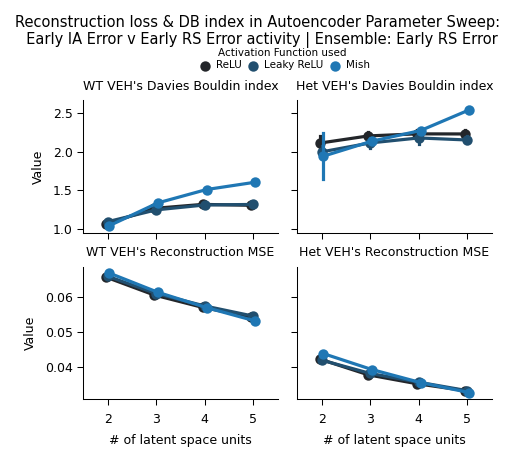

In [40]:
# Faceted pointplot: one panel per genotype
# fig,ax = plt.subplots(figsize=(8,6))
melt_sweep_df = sweep_results_df.melt(id_vars=['geno', 'activation', 'hidden_size'], 
                                        value_vars=['db_index', 'final_loss'], 
                                        var_name='metric', value_name='value')
melt_sweep_df['metric'] = melt_sweep_df['metric'].map({'db_index': 'Davies Bouldin index', 'final_loss': 'Reconstruction MSE'})
g = sns.FacetGrid(melt_sweep_df, col='geno',row = 'metric', height=1.5, aspect=1.1, sharey='row')
g.map_dataframe(sns.pointplot, x='hidden_size', y='value', hue='activation', dodge=True, errorbar='se')
g.set_titles("{col_name}'s {row_name}")
g.set_axis_labels("# of latent space units", "Value")
# Make room at top for suptitle AND legend
g.figure.subplots_adjust(top=0.8)
handles, labels = g.axes.flat[0].get_legend_handles_labels()
label_rename = {'relu': 'ReLU', 'leaky_relu': 'Leaky ReLU', 'mish': 'Mish'}
new_labels = [label_rename.get(label, label) for label in labels]
# Add legend at top center, between suptitle and plots
g.figure.legend(handles, new_labels, loc='upper center', bbox_to_anchor=(0.55, 0.93),ncol=len(new_labels),title="Activation Function used", frameon=False)
g.figure.suptitle(f"Reconstruction loss & DB index in Autoencoder Parameter Sweep:\n  {comparison.replace("_", " ")} activity | Ensemble: {ensemble.replace("_", " ")}",
                  y = 0.99, 
                  fontsize=7)
plt.savefig(f"sweep_results_{comparison}_{ensemble}.png", dpi=150, bbox_inches='tight')

In [32]:

# Print summary statistics
print("\nSummary: Mean DB Index by Configuration")
summary = sweep_results_df.groupby(['activation', 'hidden_size']).agg({
    'db_index': ['mean', 'std', 'min', 'max'],
    'final_loss': ['mean', 'std']
}).round(4)
print(summary)

# Best configuration
best_idx = sweep_results_df.groupby(['activation', 'hidden_size'])['db_index'].mean().idxmin()
print(f"\nBest configuration: activation={best_idx[0]}, hidden_size={best_idx[1]}")


Summary: Mean DB Index by Configuration
                       db_index                          final_loss        
                           mean     std     min      max       mean     std
activation hidden_size                                                     
leaky_relu 2             1.3939  0.6729  0.5775   6.5748     0.0579  0.0116
           3             1.5346  0.6046  0.6248   6.0520     0.0534  0.0111
           4             1.5983  0.6464  0.6041   6.1971     0.0502  0.0108
           5             1.5942  0.5354  0.7537   3.7423     0.0474  0.0108
mish       2             1.3416  1.7607  0.6493  30.9259     0.0591  0.0110
           3             1.6029  0.4843  0.8502   3.4952     0.0540  0.0105
           4             1.7633  0.4724  0.9145   3.9475     0.0498  0.0103
           5             1.9152  0.5531  1.0249   3.7191     0.0463  0.0098
relu       2             1.4102  0.7626  0.5082   7.0660     0.0579  0.0113
           3             1.5779  0.5884  0.6790

#### new- resample to get # of cells dropped per concat

In [ ]:
def analyze_dropped_cells(class_matrix_store, comparisons, ensembles, geno_list, 
                          n_frames_to_draw=500, n_iterations=5):
    """
    Analyze which cells are dropped during the inner join for each geno × comparison × ensemble.
    
    Returns:
        dropped_summary_df: Summary with counts per combination
        dropped_details: Dict with actual cell IDs dropped per combination
    """
    results = []
    dropped_details = {}
    
    for comparison in comparisons:
        class_0, class_1 = comparison.split("_v_")
        
        for ensemble in ensembles:
            for geno in geno_list:
                # Track across multiple resampling iterations to capture variability
                iteration_results = []
                all_dropped_ids = set()
                
                for iteration in range(n_iterations):
                    try:
                        # Resample each stage
                        ensemble_resample = resample_ensemble_stage_activity(
                            class_matrix_store, n_frames_to_draw, ensemble, geno,
                            stages_to_resample=[class_0, class_1]
                        )
                        
                        # Get cell IDs before join
                        class_0_ids = set(ensemble_resample[class_0].index)
                        class_1_ids = set(ensemble_resample[class_1].index)
                        
                        # Perform the inner join (same as fast_pack_data_local)
                        concat_matrix = ensemble_resample[class_0].join(ensemble_resample[class_1], how='inner', lsuffix='_c0', rsuffix='_c1')
                        joined_ids = set(concat_matrix.index)
                        # Calculate dropped cells
                        dropped_from_class0 = class_0_ids - joined_ids
                        dropped_from_class1 = class_1_ids - joined_ids
                        all_dropped = (class_0_ids | class_1_ids) - joined_ids
                        all_dropped_ids.update(all_dropped)
                        
                        iteration_results.append({
                            'n_class0': len(class_0_ids),'n_class1': len(class_1_ids),
                            'n_after_join': len(joined_ids),
                            'n_dropped_from_class0': len(dropped_from_class0),'n_dropped_from_class1': len(dropped_from_class1),
                            'n_total_dropped': len(all_dropped),'dropped_ids': all_dropped,})
                        
                    except KeyError as e:
                        # Handle missing data for this combination
                        iteration_results.append({'n_class0': 0, 'n_class1': 0, 'n_after_join': 0,'n_dropped_from_class0': 0, 'n_dropped_from_class1': 0,
                            'n_total_dropped': 0, 'dropped_ids': set(),'error': str(e)})
                
                # Aggregate results across iterations
                valid_results = [r for r in iteration_results if 'error' not in r]
                
                if valid_results:
                    results.append({
                        'comparison': comparison,
                        'ensemble': ensemble,
                        'geno': geno,
                        'class_0': class_0,
                        'class_1': class_1,
                        'n_class0_mean': np.mean([r['n_class0'] for r in valid_results]),
                        'n_class1_mean': np.mean([r['n_class1'] for r in valid_results]),
                        'n_after_join_mean': np.mean([r['n_after_join'] for r in valid_results]),
                        'n_dropped_mean': np.mean([r['n_total_dropped'] for r in valid_results]),
                        'n_dropped_from_class0_mean': np.mean([r['n_dropped_from_class0'] for r in valid_results]),
                        'n_dropped_from_class1_mean': np.mean([r['n_dropped_from_class1'] for r in valid_results]),
                        'pct_dropped': np.mean([r['n_total_dropped'] / max(r['n_class0'], r['n_class1'], 1) * 100 
                                               for r in valid_results]),
                        'n_unique_dropped_ids': len(all_dropped_ids),
                    })
                    
                    # Store dropped IDs
                    key = (comparison, ensemble, geno)
                    dropped_details[key] = {
                        'dropped_ids': list(all_dropped_ids),
                        'class_0_specific': list(class_0_ids - class_1_ids) if valid_results else [],
                        'class_1_specific': list(class_1_ids - class_0_ids) if valid_results else [],
                    }
                else:
                    results.append({
                        'comparison': comparison,
                        'ensemble': ensemble,
                        'geno': geno,
                        'class_0': class_0,
                        'class_1': class_1,
                        'n_class0_mean': 0, 'n_class1_mean': 0, 'n_after_join_mean': 0,
                        'n_dropped_mean': 0, 'n_dropped_from_class0_mean': 0,
                        'n_dropped_from_class1_mean': 0, 'pct_dropped': 0,
                        'n_unique_dropped_ids': 0,
                        'error': 'No valid iterations'
                    })
    
    return pd.DataFrame(results), dropped_details


def print_dropped_cell_summary(dropped_df, dropped_details, show_ids=False):
    """Pretty print the dropped cell analysis results."""
    print("=" * 80)
    print("DROPPED CELLS ANALYSIS SUMMARY")
    print("=" * 80)
    
    for _, row in dropped_df.iterrows():
        print(f"\n{row['comparison']} | Ensemble: {row['ensemble']} | Geno: {row['geno']}")
        print("-" * 60)
        print(f"  {row['class_0']}: {row['n_class0_mean']:.0f} cells")
        print(f"  {row['class_1']}: {row['n_class1_mean']:.0f} cells")
        print(f"  After inner join: {row['n_after_join_mean']:.0f} cells")
        print(f"  Dropped: {row['n_dropped_mean']:.0f} cells ({row['pct_dropped']:.1f}%)")
        print(f"    - From {row['class_0']}: {row['n_dropped_from_class0_mean']:.0f}")
        print(f"    - From {row['class_1']}: {row['n_dropped_from_class1_mean']:.0f}")
        
        if show_ids:
            key = (row['comparison'], row['ensemble'], row['geno'])
            if key in dropped_details and dropped_details[key]['dropped_ids']:
                ids = dropped_details[key]['dropped_ids'][:10]  # Show first 10
                print(f"  Sample dropped IDs: {ids}")
                if len(dropped_details[key]['dropped_ids']) > 10:
                    print(f"    ... and {len(dropped_details[key]['dropped_ids']) - 10} more")

In [34]:
# Define combinations of interest
comparisons_to_analyze = [
    'Early_IA_Error_v_Early_RS_Error',
    'Early_IA_Correct_v_Early_RS_Correct',
]

ensembles_to_analyze = [
    'Early_IA_Correct',
    'Early_IA_Error', 
    'Early_RS_Correct',
    'Early_RS_Error',
]

geno_list_to_analyze = geno_order  # Use all genotypes

# Run the analysis
print("Analyzing dropped cells across all combinations...")
print(f"Comparisons: {comparisons_to_analyze}")
print(f"Ensembles: {ensembles_to_analyze}")
print(f"Genotypes: {geno_list_to_analyze}")
print()

dropped_df, dropped_details = analyze_dropped_cells(
    class_matrix_store=class_matrix_store,
    comparisons=comparisons_to_analyze,
    ensembles=ensembles_to_analyze,
    geno_list=geno_list_to_analyze,
    n_frames_to_draw=500,
    n_iterations=3  # Average over 3 resampling iterations
)

# Print summary
print_dropped_cell_summary(dropped_df, dropped_details, show_ids=True)

Analyzing dropped cells across all combinations...
Comparisons: ['Early_IA_Error_v_Early_RS_Error', 'Early_IA_Correct_v_Early_RS_Correct']
Ensembles: ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']
Genotypes: ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']

DROPPED CELLS ANALYSIS SUMMARY

Early_IA_Error_v_Early_RS_Error | Ensemble: Early_IA_Correct | Geno: WT VEH
------------------------------------------------------------
  Early_IA_Error: 59 cells
  Early_RS_Error: 73 cells
  After inner join: 43 cells
  Dropped: 46 cells (63.0%)
    - From Early_IA_Error: 16
    - From Early_RS_Error: 30
  Sample dropped IDs: ['7_4_WT_RS1-7', '13_4_WT_RS1-21', '13_4_WT_RS1-70', '13_4_WT_RS1-5', '13_6_WT_RS1-197', '7_4_WT_RS1-73', '13_4_WT_RS1-117', '13_6_WT_RS1-126', '13_6_WT_RS1-69', '13_6_WT_RS1-14']
    ... and 36 more

Early_IA_Error_v_Early_RS_Error | Ensemble: Early_IA_Correct | Geno: Het VEH
------------------------------------------------------------
  Early_IA

In [41]:
dropped_df

,comparison,ensemble,geno,class_0,class_1,n_class0_mean,n_class1_mean,n_after_join_mean,n_dropped_mean,n_dropped_from_class0_mean,n_dropped_from_class1_mean,pct_dropped,n_unique_dropped_ids
0,Early_IA_Error_v_Early_RS_Error,Early_IA_Correct,WT VEH,Early_IA_Error,Early_RS_Error,59.0,73.0,43.0,46.0,16.0,30.0,63.013699,46
1,Early_IA_Error_v_Early_RS_Error,Early_IA_Correct,Het VEH,Early_IA_Error,Early_RS_Error,33.0,160.0,33.0,127.0,0.0,127.0,79.375000,127
2,Early_IA_Error_v_Early_RS_Error,Early_IA_Correct,Het CLNZ,Early_IA_Error,Early_RS_Error,76.0,108.0,76.0,32.0,0.0,32.0,29.629630,32
3,Early_IA_Error_v_Early_RS_Error,Early_IA_Correct,Het postCLNZ,Early_IA_Error,Early_RS_Error,92.0,133.0,92.0,41.0,0.0,41.0,30.827068,41
4,Early_IA_Error_v_Early_RS_Error,Early_IA_Error,WT VEH,Early_IA_Error,Early_RS_Error,56.0,47.0,37.0,29.0,19.0,10.0,51.785714,29
5,Early_IA_Error_v_Early_RS_Error,Early_IA_Error,Het VEH,Early_IA_Error,Early_RS_Error,26.0,77.0,26.0,51.0,0.0,51.0,66.233766,51
6,Early_IA_Error_v_Early_RS_Error,Early_IA_Error,Het CLNZ,Early_IA_Error,Early_RS_Error,80.0,93.0,80.0,13.0,0.0,13.0,13.978495,13
7,Early_IA_Error_v_Early_RS_Error,Early_IA_Error,Het postCLNZ,Early_IA_Error,Early_RS_Error,92.0,92.0,92.0,0.0,0.0,0.0,0.000000,0
8,Early_IA_Error_v_Early_RS_Error,Early_RS_Correct,WT VEH,Early_IA_Error,Early_RS_Error,39.0,54.0,32.0,29.0,7.0,22.0,53.703704,29
9,Early_IA_Error_v_Early_RS_Error,Early_RS_Correct,Het VEH,Early_IA_Error,Early_RS_Error,15.0,63.0,15.0,48.0,0.0,48.0,76.190476,48


geno,Het CLNZ,Het VEH,Het postCLNZ,WT VEH
ensemble,,,,
Early_IA_Correct,0.0,24.375000,0.0,0.0
Early_IA_Error,0.0,0.000000,0.0,0.0
Early_RS_Correct,0.0,15.873016,0.0,0.0
Early_RS_Error,0.0,10.000000,0.0,0.0



Saved: dropped_cells_summary_13_Jan_2026.csv


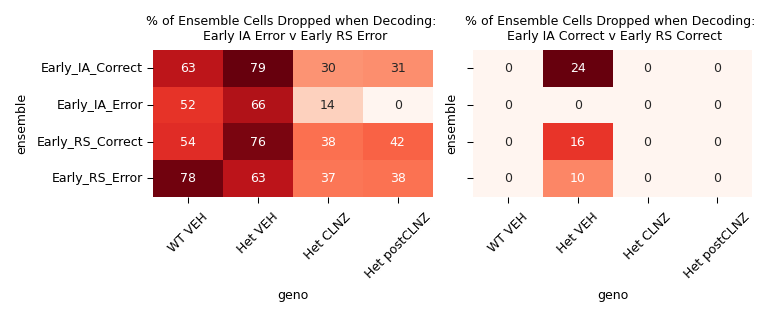

In [65]:
# Visualize dropped cells and save results
fig, axes = plt.subplots(1, 2, figsize=(5, 2), layout='constrained', sharey= True)

# Plot 1: Heatmap of % dropped by ensemble × geno (averaged across comparisons)
for c, comp in enumerate(comparisons_to_analyze):
    ax = axes[c]
    comp_df = dropped_df.loc[dropped_df['comparison'] == comp]
    pivot_pct = comp_df.pivot(index=['ensemble'], columns='geno', values='pct_dropped').loc[:, geno_order]
    sns.heatmap(pivot_pct, annot=True, fmt='.0f', cmap='Reds', ax=ax, cbar = False)
    set_labels(ax = ax, label_dict = {'x':'Genotype', 'y':'Ensemble', 
                                      'title':f'% of Ensemble Cells Dropped when Decoding: \n {comp.replace("_", " ")}'}) 
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

plt.savefig(f"dropped_cells_analysis_{date_tag}.png", dpi=150, bbox_inches='tight')
# Save detailed results
dropped_df.to_csv(f"dropped_cells_summary_{date_tag}.csv", index=False)
print(f"\nSaved: dropped_cells_summary_{date_tag}.csv")

In [36]:
def resample_ensemble_stage_activity(class_matrix_store,
                                     n_frames_to_draw:int=500,
                                     ensemble:str = "",
                                     geno:str="",
                                     stages_to_resample:list  = ['Early_IA_Correct', 'Early_RS_Correct', 'Early_IA_Error', 'Early_RS_Error'],
                                     **kwargs):
    '''To iterate over specified stages and return dict containing N resampled frame for each stage. Requires 'resample_into_class_matrix'
    '''
    ensemble_resample_in_phase_dict = {}
    for class_name in stages_to_resample: #store the versions for this bootstrap run
        class_mat = resample_into_class_matrix(class_matrix_store,n_frames_to_draw,ensemble, class_name, geno)
        ensemble_resample_in_phase_dict[class_name] = class_mat
        
    return ensemble_resample_in_phase_dict